# use mapping310 env

In [1]:
import geopandas as gpd
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv('MeasuredSectionStats.csv')

facies_colors = pd.read_excel('Facies Rosetta Stone.xlsx')
code_col = 'facies_code_MOST'
color_col = 'color_hex_measured_section'
name_col = 'name' if 'name' in facies_colors.columns else facies_colors.columns[0]
name_ms_col = 'name_measured_section' if 'name_measured_section' in facies_colors.columns else name_col
fc = facies_colors.dropna(subset=[code_col]).drop_duplicates(subset=[code_col], keep='first')
facies_color_map = dict(zip(fc[code_col].astype(int), fc[color_col].astype(str)))
facies_label_map = dict(zip(fc[code_col].astype(int), fc[name_col].astype(str)))
facies_name_ms_map = dict(zip(fc[code_col].astype(int), fc[name_ms_col].astype(str)))


In [7]:
df.name.unique()

array(['ArrowCanyon', 'BadGirlsGully', 'BadtotheBone', 'BitterwellCynNE',
       'BloodSweatandTears', 'BrushyMesaFaultBlock', 'BurroN',
       'ChannelWall1', 'ChannelWall2', 'ChannelWall3NE',
       'CodornizCanyon1', 'CodornizCanyon2', 'CodornizCanyon2Annex',
       'CodornizCanyon3', 'ColSec08ANEW', 'ColSec08jmc.CNV_p', 'ColSec09',
       'ColSec13rev2002new', 'Colleen02', 'Colleen04', 'Colleen06',
       'Colleen1', 'Colleen10', 'Colleen12', 'Colleen14', 'Colleen14a',
       'Colleen15', 'Colleen15(2ndrun)', 'Colleen1_1', 'Colleen3',
       'Colleen5', 'Colleen7', 'ColleenCanyon08', 'ColleenCanyon4.5',
       'CookyPtSouth', 'DanceHall', 'DanceHallEast',
       'DancingDutchSandwich', 'EagleNest', 'FBc2', 'FaultWall2', 'Fbm',
       'Fbm_1', 'GardnersFolly', 'GnatGrabenGulley', 'HOTMONDAY',
       'Hoagie', 'HogueCanyon', 'HogueWest', 'HotMondayChannelAxis',
       'JanesWindowA', 'JanesWindowB', 'LONGWALK', 'LobeWall1',
       'LobeWall2_dp', 'LowerChannel', 'LwrCodornizAnnex',
 

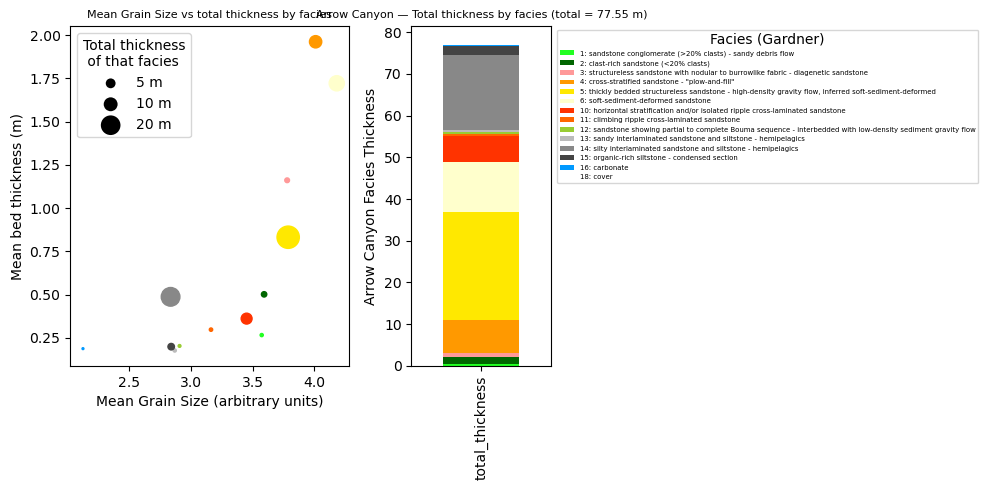

In [14]:
# Filter to Arrow Canyon
arrow = df[df['name'] == 'ArrowCanyon'].copy()

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'width_ratios': [2, 1]})

# Subplot 0: scatter (mean grainsize vs total thickness)
arrow_scatter_colors = arrow['Facies'].map(facies_color_map).fillna('#cccccc')
arrow.plot(kind='scatter', x='mean_grainsize', y='mean_thickness', c=arrow_scatter_colors, s=arrow['total_thickness'] * 10, ax=ax0)
ax0.set_xlabel('Mean Grain Size (arbitrary units)')
ax0.set_ylabel('Mean bed thickness (m)')
ax0.set_title('Mean Grain Size vs total thickness by facies', fontsize=8)
# Size legend: black circles showing what thickness each size represents (same scale s=thickness*10)
size_legend_m = [5, 10, 20]
for t in size_legend_m:
    ax0.scatter([], [], s=t * 10, c='black', label=f'{t} m', edgecolors='none')
ax0.legend(loc='upper left', title='Total thickness\n of that facies')

# Subplot 1: stacked bar of total thickness by facies
stacked = arrow.set_index('Facies')['total_thickness'].to_frame().T
colors = [facies_color_map.get(f, '#cccccc') for f in stacked.columns]
stacked.plot(kind='bar', stacked=True, ax=ax1, color=colors, legend=True, width=0.6)
section_total = arrow['section_total_thickness'].iloc[0] if 'section_total_thickness' in arrow.columns else stacked.values.sum()
ax1.set_ylabel('Arrow Canyon Facies Thickness')
ax1.set_title(f'Arrow Canyon — Total thickness by facies (total = {section_total:.2f} m)', fontsize=8)
legend_labels = [f"{f}: {facies_name_ms_map.get(f, str(f))}" for f in stacked.columns]
leg = ax1.get_legend()
if leg:
    ax1.legend(leg.legend_handles, legend_labels, title='Facies (Gardner)', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=5)

plt.tight_layout()
plt.show()

